## Compare the ring and fibonacci spiral methods

In [ ]:
import numpy as np
import opmsim as opm
from opmsim.rays import PolarRays
from opmsim.dipole_source import DipoleSource
from opmsim.optical_system import OpticalSystem
from opmsim.optical_elements import SineLens, LinearPolariser, FlatMirror
import opmsim.anisotropy as anisotropy
import matplotlib.pyplot as plt

%matplotlib widget

c:\users\leo\python\opmsim\opmsim\rays.py:83: RuntimeWarning: invalid value encountered in scalar divide
  self.ray_density = self.n / np.sum(area_elements)  # so values dont change with ray number


In [2]:
# List of NAs to check
NA_list = np.linspace(0.5, 0.99, 3, endpoint=True)

In [3]:
phi_d_angles = np.linspace(0, 2 * np.pi, 9)  # dipole azimuth
alpha_d_angles = np.linspace(0, np.pi/2, 3)  # dipole polar

aniso_grid = np.zeros((len(NA_list), len(phi_d_angles), len(alpha_d_angles)))
aniso_grid_theory = np.zeros((len(NA_list), len(phi_d_angles), len(alpha_d_angles)))
aniso_grid_rings = np.zeros((len(NA_list), len(phi_d_angles), len(alpha_d_angles)))
aniso_grid_theory_rings = np.zeros((len(NA_list), len(phi_d_angles), len(alpha_d_angles)))

In [4]:
# Generate element lists for the various NAs in NA_list

# element_lists is 1 collecting lens (standard), which involves an energy scaling due to area elements going from curved to flat
# element_lists_mirror is 1 lens with a mirror -- check if this is valid?
# element_lists_curved is 2 lenses to check result without the energy scaling due to area element scaling

element_lists = [[SineLens(NA=NA_list[i], focal_length=1)] for i in range(len(NA_list))]
element_lists_mirror = [[SineLens(NA=NA_list[i], focal_length=1), FlatMirror()] for i in range(len(NA_list))]
element_lists_curved = [[SineLens(NA=NA_list[i], focal_length=1), SineLens(NA=NA_list[i], focal_length=1)] for i in range(len(NA_list))]
element_lists_mirror_curved = [[SineLens(NA=NA_list[i], focal_length=1), SineLens(NA=NA_list[i], focal_length=1), FlatMirror()] for i in range(len(NA_list))]
element_lists_3 = [[SineLens(NA=NA_list[i], focal_length=1), SineLens(NA=NA_list[i], focal_length=1), SineLens(NA=NA_list[i], focal_length=1)] for i in range(len(NA_list))]


Lens 0: flipped=False
Lens 1: flipped=True
Plotting debug plots False
Element list: [<opmsim.optical_elements.sine_lens.SineLens object at 0x000002197FA0C620>, <opmsim.optical_elements.sine_lens.SineLens object at 0x000002197FB1C7A0>] (2 elements)
Tracing <opmsim.optical_elements.sine_lens.SineLens object at 0x000002197FA0C620> (1/2) label: 
Tracing <opmsim.optical_elements.sine_lens.SineLens object at 0x000002197FB1C7A0> (2/2) label: 
Final wavefront is curved!


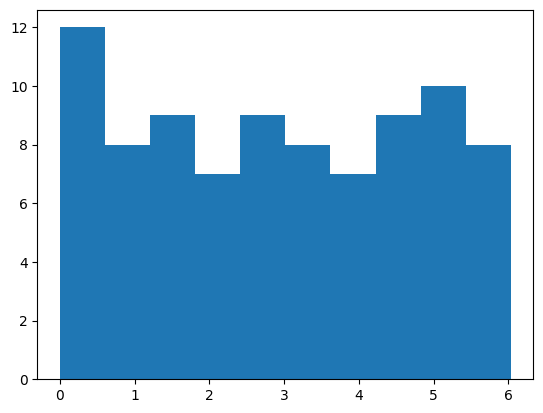

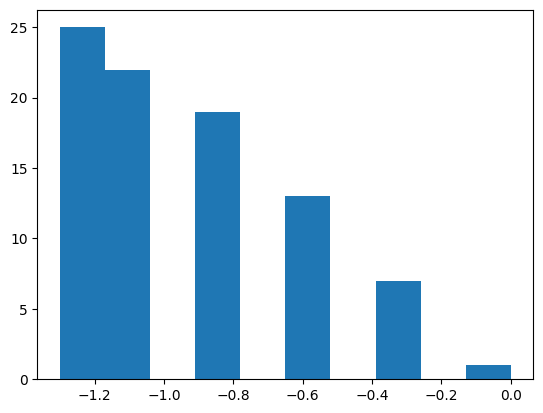

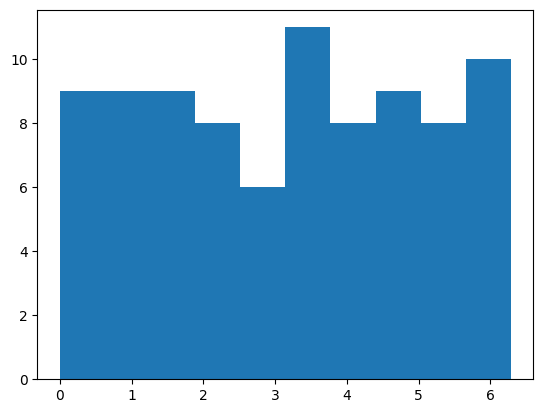

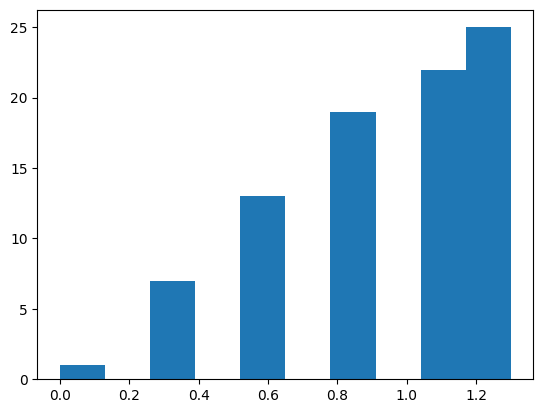

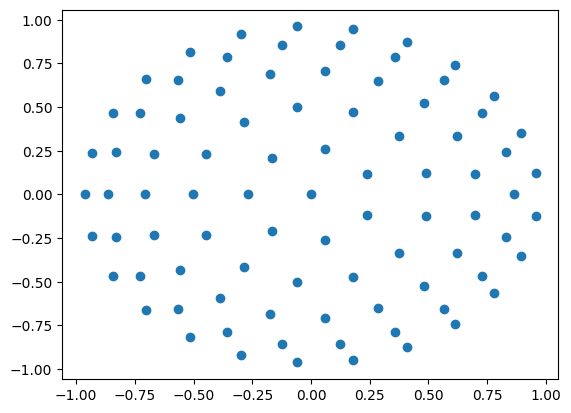

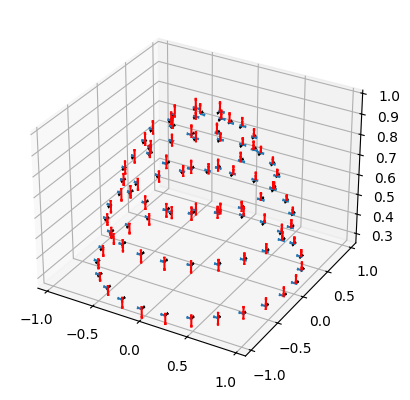

0 rays escaped out of 87
[[0.00000000e+00]
 [3.72860037e-31]
 [1.10933565e-31]
 [9.43705673e-33]
 [2.78104284e-31]
 [3.39734042e-31]
 [2.77333912e-32]
 [6.24001302e-32]
 [0.00000000e+00]
 [4.93038066e-32]
 [1.97215226e-31]
 [3.77482269e-32]
 [6.93334780e-33]
 [3.08148791e-33]
 [3.08148791e-33]
 [3.08148791e-33]
 [1.23259516e-32]
 [7.70371978e-34]
 [4.33334237e-34]
 [1.92592994e-32]
 [3.08148791e-33]
 [3.08148791e-33]
 [2.77333912e-32]
 [3.08148791e-33]
 [7.70371978e-34]
 [4.81482486e-33]
 [3.15900659e-31]
 [4.93038066e-32]
 [6.24001302e-32]
 [1.10933565e-31]
 [3.08148791e-33]
 [1.23259516e-32]
 [3.08148791e-33]
 [3.08148791e-33]
 [1.23259516e-32]
 [2.03426350e-33]
 [1.92592994e-34]
 [2.77333912e-32]
 [7.70371978e-32]
 [0.00000000e+00]
 [7.70371978e-34]
 [3.08148791e-33]
 [9.32150093e-32]
 [7.70371978e-34]
 [6.93334780e-33]
 [5.82593808e-33]
 [2.54704235e-32]
 [4.93038066e-32]
 [1.50992908e-31]
 [4.93038066e-32]
 [3.08148791e-33]
 [7.70371978e-34]
 [0.00000000e+00]
 [3.77482269e-32]
 [3

c:\users\leo\python\opmsim\opmsim\visualization\pupil_plot.py:99: UserWarning: The following kwargs were not used by contour: 'title'
  pc1 = ax.tricontourf(x, y, data, title="", cmap=cmap, levels=levels,
c:\users\leo\python\opmsim\opmsim\optical_system.py:135: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  pupil_plot.show()


<Figure size 700x300 with 0 Axes>

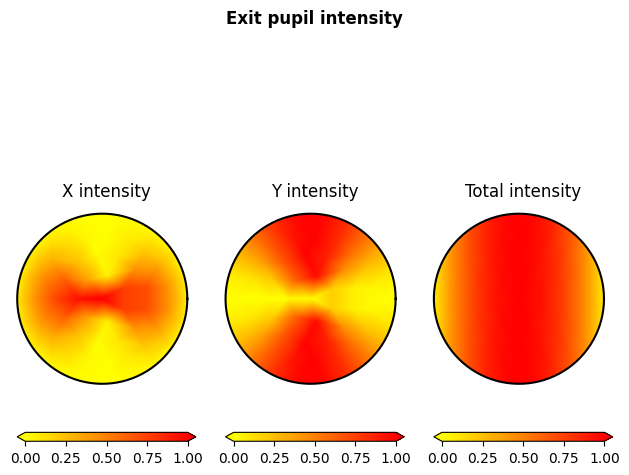

In [5]:
source_a = DipoleSource((0, 0))
os = OpticalSystem(elements=element_lists_curved[-1], source=source_a)
os.default_ray_count = 100
os.ray_generation_method = 'rings'
os.trace_system(plot_pupil=True)

In [5]:
def compare_anisotropy_with_angle(NA_list, element_list_na, phi_angles, alpha_angles, ray_method='fibonacci'):
    """
    Generate anisotropy measurements for a given list of elements/NAs and dipole orientations as a 3D matrix,
    shape is (NAs, phis, alphas)

    Args:
        NA_list (numpy.ndarray): list of NAs that define the element lists
        element_list_na (list[list[Element]]): list of element lists for each NA, e.g. [[SineLens(NA=0.1)], [SineLens(NA=0.2)]]
        phi_angles (numpy.ndarray): numpy array of dipole phi_d angles to test
        alpha_angles (numpy.ndarray): numpy array of dipole alpha_d angles to test
        ray_method (str): method to generate ray cone: fibonacci or rings. Defaults to 'fibonacci'

    Returns:
        (numpy.ndarray, numpy.ndarray): anisotropy for each NA, phi, alpha: returned as tuple of (simulated, theory)
    """
    aniso_grid = np.zeros((len(NA_list), len(phi_angles), len(alpha_angles)))
    aniso_grid_theory = np.zeros((len(NA_list), len(phi_angles), len(alpha_angles)))
    for i, NA in enumerate(NA_list):
        for m, theta in enumerate(alpha_angles):
            for n, phi in enumerate(phi_angles):
                print("phi:", phi, "theta", theta)

                # Fibonacci method
                source_a = DipoleSource((phi, theta))
                os = OpticalSystem(elements=element_list_na[i], source=source_a)
                os.ray_generation_method = ray_method
                os.trace_system(plot_pupil=False)
                aniso_grid[i, n, m] = anisotropy.calculate_anisotropy(os.get_detector(), np.pi/2)
                aniso_grid_theory[i, n, m] = anisotropy.theoretical_anisotropy(NA, (phi, theta))
    return (aniso_grid, aniso_grid_theory)

In [6]:
aniso_grid_fib, aniso_grid_fib_theory = compare_anisotropy_with_angle(
    NA_list, element_lists_curved, phi_d_angles, alpha_d_angles)
aniso_grid_rings, aniso_grid_rings_theory = compare_anisotropy_with_angle(
    NA_list, element_lists_curved, phi_d_angles, alpha_d_angles, ray_method='rings')

phi: 0.0 theta 0.0
Lens 0: flipped=False
Lens 1: flipped=True
Plotting debug plots False
Element list: [<opmsim.optical_elements.sine_lens.SineLens object at 0x000001B757B4BC20>, <opmsim.optical_elements.sine_lens.SineLens object at 0x000001B756A2FD40>] (2 elements)
Tracing <opmsim.optical_elements.sine_lens.SineLens object at 0x000001B757B4BC20> (1/2) label: 
Tracing <opmsim.optical_elements.sine_lens.SineLens object at 0x000001B756A2FD40> (2/2) label: 
Final wavefront is curved!
0 rays escaped out of 1001
area scaling [1. 1. 1. ... 1. 1. 1.]
phi: 0.7853981633974483 theta 0.0
Lens 0: flipped=False
Lens 1: flipped=True
Plotting debug plots False
Element list: [<opmsim.optical_elements.sine_lens.SineLens object at 0x000001B757B4BC20>, <opmsim.optical_elements.sine_lens.SineLens object at 0x000001B756A2FD40>] (2 elements)
Tracing <opmsim.optical_elements.sine_lens.SineLens object at 0x000001B757B4BC20> (1/2) label: 
Tracing <opmsim.optical_elements.sine_lens.SineLens object at 0x000001B7

NAs [0.5   0.745 0.99 ]
1 3
phis [0.         0.78539816 1.57079633 2.35619449 3.14159265 3.92699082
 4.71238898 5.49778714 6.28318531]
theta [0.         0.78539816 1.57079633]
NAs [0.5   0.745 0.99 ]
1 3
phis [0.         0.78539816 1.57079633 2.35619449 3.14159265 3.92699082
 4.71238898 5.49778714 6.28318531]
theta [0.         0.78539816 1.57079633]


Text(0.5, 0.98, 'Anisotropy residuals (ring method)')

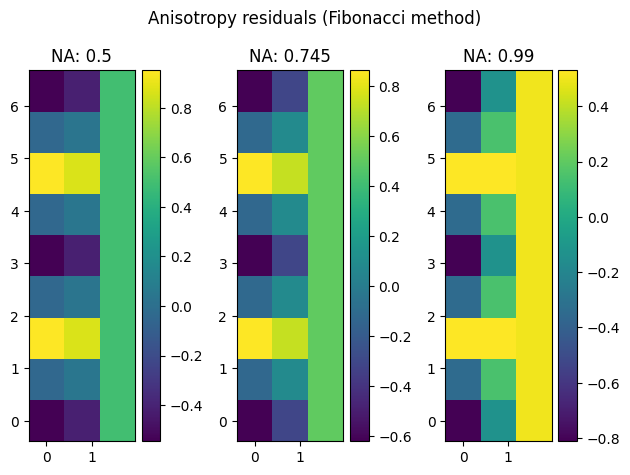

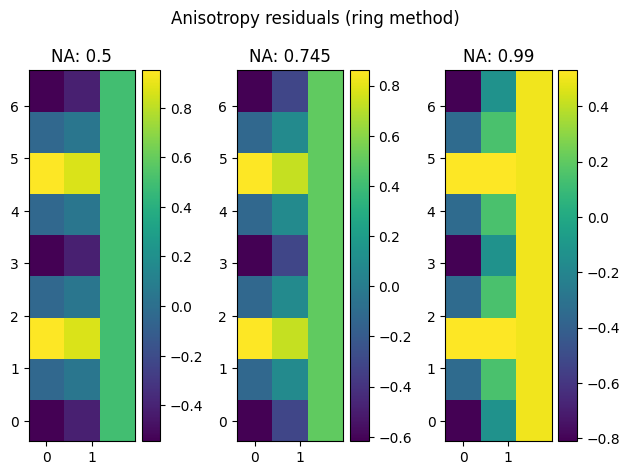

In [7]:
# Plot the results in a heatmap grid

resids = aniso_grid_fib_theory-aniso_grid_fib

# print(resids)
f = plt.figure()
n_plots = resids.shape[0]
n_cols = 3
n_rows = int(np.ceil(n_plots / n_cols))
print("NAs", NA_list)
print(n_rows, n_cols)

xlabs = print("phis", phi_d_angles)
print("theta", alpha_d_angles)

for n in range(resids.shape[0]):
    row = int(np.ceil(n / n_cols))
    col = (n % n_cols) + 1
    ax = f.add_subplot(n_rows, n_cols, n+1)
    pc = ax.pcolormesh(alpha_d_angles, phi_d_angles, resids[n, :, :],\
        shading='auto')    
    f.colorbar(pc)
    ax.set_title(f"NA: {NA_list[n]}")

f.set_tight_layout(True)
f.suptitle("Anisotropy residuals (Fibonacci method)")

resids_rings = aniso_grid_rings_theory-aniso_grid_rings

# print(resids)
f_rings = plt.figure()
n_plots = resids.shape[0]
n_cols = 3
n_rows = int(np.ceil(n_plots / n_cols))
print("NAs", NA_list)
print(n_rows, n_cols)

xlabs = print("phis", phi_d_angles)
print("theta", alpha_d_angles)

for n in range(resids.shape[0]):
    row = int(np.ceil(n / n_cols))
    col = (n % n_cols) + 1
    ax_rings = f_rings.add_subplot(n_rows, n_cols, n+1)
    pc = ax_rings.pcolormesh(alpha_d_angles, phi_d_angles, resids_rings[n, :, :],\
        shading='auto')    
    f_rings.colorbar(pc)
    ax_rings.set_title(f"NA: {NA_list[n]}")

f_rings.set_tight_layout(True)
f_rings.suptitle("Anisotropy residuals (ring method)")